In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#En caso de no poder cargar el archivo con seaborns leerlo con pandas
df= pd.read_csv("Citas_Digital_final.csv")


In [3]:
df.shape

(666, 15)

In [4]:
df.head()

,Unnamed: 0,BDC,Fecha,Nombre Cliente,Estatus de Lead,Potencial de compra,PDM,SDC,Venta,Asesor Asignado,¿Por que no ha visitado la agencia?,¿Por que no hay solicitud de credito?,¿Por que no hubo prueba de manejo ?,¿Por que no hubo proceso wow?,¿Por que se asigno antes de vistar piso?
0,0,Saul,Abril 2025,Guillermo,Finalizado,90%,True,False,False,Nancy,"Ya visito la Agencia el dia jueves 17, intere...","Pide arrendamiento, unicamente se esta en espe...","Si, hizo prueba de manejo","Si recibio procesos wow, estuvo en la agencia ...","No, se espero a que visitara la agencia para s..."
1,1,Saul,Abril 2025,Roberto,Finalizado,40%,False,False,False,Victor,Ya visito la Agencia el dia 3 de abril,Por que primero queria manejar las unidad,No habia unidad GS8 HEV para prueba de manejo,"Si recibio procesos wow, sin embargo no quizo ...",Se asigno hasta que visitara Piso
2,2,Saul,Abril 2025,Irving,Finalizado,85%,False,False,False,Alan,Ya visito la agencia el dia 21 de abril,"Firmo solicitud, sin embargo despues comento q...",Por que no habia unidad para prueba de manejo,"Si se realizo el proceso wow, los clientes se ...",Se asigno hasta que visitara Piso
3,3,Saul,Abril 2025,Oswaldo,Venta,90%,False,False,True,Mauricio,El cliente vive en Tabasco Villahermosa,Sera compra de contado,"Ya la manejo en Villahermosa, sin embargo por ...","Las veces que se le ha marcado, agradece mucho...","Necesitabamos sacar el apartado, por eso se as..."
4,4,Saul,Abril 2025,Rodrigo,Finalizado,90%,True,False,False,Mauricio,"Visito la agencia el mes pasado, y nos visita ...",Hoy visita nuevamente la agencia y se firma so...,"La primera vez que nos visito, realizo PDM",Si recibio el proceso wow la primera vez que n...,Se asigno hasta que visitara Piso la primera ...


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 666 entries, 0 to 665
Data columns (total 15 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   Unnamed: 0                                666 non-null    int64
 1   BDC                                       666 non-null    str  
 2   Fecha                                     666 non-null    str  
 3   Nombre Cliente                            666 non-null    str  
 4   Estatus de Lead                           666 non-null    str  
 5   Potencial de compra                       666 non-null    str  
 6   PDM                                       666 non-null    bool 
 7   SDC                                       666 non-null    bool 
 8   Venta                                     666 non-null    str  
 9   Asesor Asignado                           666 non-null    str  
 10  ¿Por que no ha visitado la agencia?       666 non-null    str  
 11  ¿Por

In [6]:
df = df.drop(columns=["Unnamed: 0"])

In [7]:
df['Potencial de compra'].unique()

<StringArray>
[         '90%',          '40%',          '85%',          '20%',
          '50%',          '80%',         '100%',          '60%',
          '70%',          '95%',          '75%', 'Sin registro',
          '65%',          '30%']
Length: 14, dtype: str

In [8]:
df = df.replace("Sin registro", np.nan)

In [9]:
df['Potencial de compra'].unique()

<StringArray>
[ '90%',  '40%',  '85%',  '20%',  '50%',  '80%', '100%',  '60%',  '70%',
  '95%',  '75%',    nan,  '65%',  '30%']
Length: 14, dtype: str

In [10]:
df.isnull().sum()

BDC                                           8
Fecha                                         0
Nombre Cliente                                0
Estatus de Lead                              14
Potencial de compra                          55
PDM                                           0
SDC                                           0
Venta                                         3
Asesor Asignado                              10
¿Por que no ha visitado la agencia?         173
¿Por que no hay solicitud de credito?       287
¿Por que no hubo prueba de manejo ?         311
¿Por que no hubo proceso wow?               302
¿Por que se asigno antes de vistar piso?    313
dtype: int64

In [11]:
df["Potencial de compra"] = (df["Potencial de compra"].str.replace("%", "", regex=False)
    .astype(float))

In [ ]:
#Convertimos los datos a númericos
df["PDM"] = df["PDM"].astype(int)
df["SDC"] = df["SDC"].astype(int)

In [13]:
df["Venta"] = df["Venta"].map({"True": 1, "False": 0})

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 666 entries, 0 to 665
Data columns (total 14 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   BDC                                       658 non-null    str    
 1   Fecha                                     666 non-null    str    
 2   Nombre Cliente                            666 non-null    str    
 3   Estatus de Lead                           652 non-null    str    
 4   Potencial de compra                       611 non-null    float64
 5   PDM                                       666 non-null    int64  
 6   SDC                                       666 non-null    int64  
 7   Venta                                     663 non-null    float64
 8   Asesor Asignado                           656 non-null    str    
 9   ¿Por que no ha visitado la agencia?       493 non-null    str    
 10  ¿Por que no hay solicitud de credito?     379 non

In [15]:
df.head()

,BDC,Fecha,Nombre Cliente,Estatus de Lead,Potencial de compra,PDM,SDC,Venta,Asesor Asignado,¿Por que no ha visitado la agencia?,¿Por que no hay solicitud de credito?,¿Por que no hubo prueba de manejo ?,¿Por que no hubo proceso wow?,¿Por que se asigno antes de vistar piso?
0,Saul,Abril 2025,Guillermo,Finalizado,90.0,1,0,0.0,Nancy,"Ya visito la Agencia el dia jueves 17, intere...","Pide arrendamiento, unicamente se esta en espe...","Si, hizo prueba de manejo","Si recibio procesos wow, estuvo en la agencia ...","No, se espero a que visitara la agencia para s..."
1,Saul,Abril 2025,Roberto,Finalizado,40.0,0,0,0.0,Victor,Ya visito la Agencia el dia 3 de abril,Por que primero queria manejar las unidad,No habia unidad GS8 HEV para prueba de manejo,"Si recibio procesos wow, sin embargo no quizo ...",Se asigno hasta que visitara Piso
2,Saul,Abril 2025,Irving,Finalizado,85.0,0,0,0.0,Alan,Ya visito la agencia el dia 21 de abril,"Firmo solicitud, sin embargo despues comento q...",Por que no habia unidad para prueba de manejo,"Si se realizo el proceso wow, los clientes se ...",Se asigno hasta que visitara Piso
3,Saul,Abril 2025,Oswaldo,Venta,90.0,0,0,1.0,Mauricio,El cliente vive en Tabasco Villahermosa,Sera compra de contado,"Ya la manejo en Villahermosa, sin embargo por ...","Las veces que se le ha marcado, agradece mucho...","Necesitabamos sacar el apartado, por eso se as..."
4,Saul,Abril 2025,Rodrigo,Finalizado,90.0,1,0,0.0,Mauricio,"Visito la agencia el mes pasado, y nos visita ...",Hoy visita nuevamente la agencia y se firma so...,"La primera vez que nos visito, realizo PDM",Si recibio el proceso wow la primera vez que n...,Se asigno hasta que visitara Piso la primera ...


In [16]:
df.isnull().sum()

BDC                                           8
Fecha                                         0
Nombre Cliente                                0
Estatus de Lead                              14
Potencial de compra                          55
PDM                                           0
SDC                                           0
Venta                                         3
Asesor Asignado                              10
¿Por que no ha visitado la agencia?         173
¿Por que no hay solicitud de credito?       287
¿Por que no hubo prueba de manejo ?         311
¿Por que no hubo proceso wow?               302
¿Por que se asigno antes de vistar piso?    313
dtype: int64

In [17]:
#Para poder trabajar en la regresión con esta variable, creamos un set donde quitamos los elementos identificados como NAN
df_potencial = df.dropna(subset=["Potencial de compra", "Venta"])

In [18]:
df_potencial.shape

(608, 14)

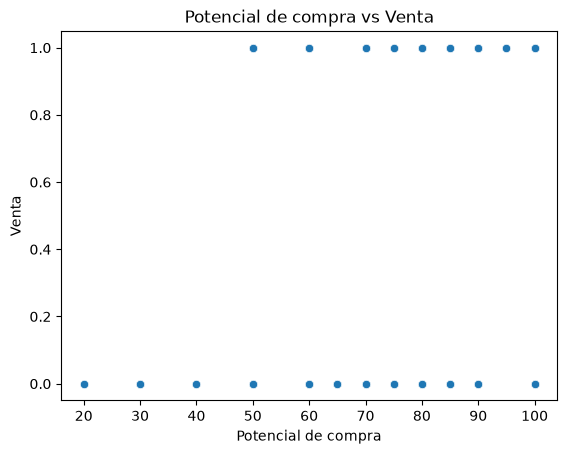

In [19]:
sns.scatterplot( x="Potencial de compra", y="Venta",data=df_potencial)

plt.title("Potencial de compra vs Venta")
plt.xlabel("Potencial de compra")
plt.ylabel("Venta")
plt.show()

In [20]:
Vars_Indep = df_potencial[["Potencial de compra"]]
Var_Dep = df_potencial["Venta"]

In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [22]:
model.fit(X=Vars_Indep, y=Var_Dep)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.01]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Potencial de compra']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.3645
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [23]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['Potencial de compra'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.00628074]),
 'rank_': np.int64(1),
 'singular_': array([303.36706965]),
 'intercept_': np.float64(-0.36450410328262683)}

Venta=−0.3645​+0.00628​(Potencial de compra)

In [24]:
model.score(Vars_Indep, Var_Dep)

0.06919444736263702

In [25]:
y_pred = model.predict(X=df_potencial[["Potencial de compra"]])
y_pred

array([ 0.2007624 , -0.11327455,  0.1693587 ,  0.2007624 ,  0.2007624 ,
        0.1693587 , -0.23888933, -0.05046716,  0.13795501,  0.13795501,
        0.26356978,  0.13795501,  0.01234023,  0.2007624 ,  0.01234023,
        0.13795501,  0.13795501,  0.01234023,  0.26356978,  0.13795501,
       -0.23888933,  0.13795501,  0.07514762,  0.13795501,  0.13795501,
        0.07514762, -0.11327455,  0.26356978,  0.07514762,  0.07514762,
        0.13795501,  0.13795501,  0.13795501,  0.07514762,  0.2007624 ,
        0.07514762,  0.2007624 ,  0.13795501,  0.07514762,  0.2007624 ,
        0.13795501,  0.23216609,  0.13795501,  0.13795501,  0.13795501,
        0.13795501,  0.07514762,  0.13795501,  0.10655131,  0.2007624 ,
        0.1693587 ,  0.07514762,  0.2007624 ,  0.1693587 ,  0.13795501,
        0.07514762,  0.13795501,  0.2007624 ,  0.2007624 ,  0.2007624 ,
        0.1693587 ,  0.10655131,  0.13795501,  0.2007624 ,  0.07514762,
        0.07514762,  0.2007624 ,  0.2007624 ,  0.2007624 , -0.05

In [26]:
df_potencial = df_potencial.copy()

df_potencial["Predicciones"] = y_pred

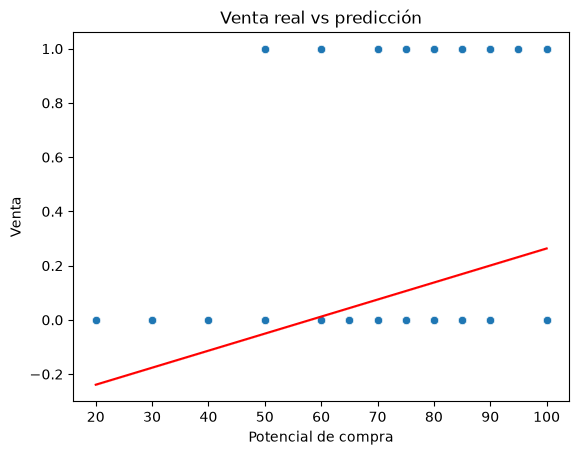

In [27]:
sns.scatterplot(x="Potencial de compra", y="Venta", data=df_potencial)

sns.lineplot(x="Potencial de compra",y="Predicciones",data=df_potencial,color="red")

plt.title("Venta real vs predicción")
plt.show()

Como Venta solo puede valer 0 o 1, las observaciones se concentran en esos dos niveles. La línea de regresión representa la tendencia promedio entre el potencial de compra y la ocurrencia de una venta.


En esta regresión el valor esperado de Venta puede interpretarse como una probabilidad estimada de observar una venta.

In [28]:
#Selecciono las columnas numéricas que nos interesan
df_correlacion = df[["Potencial de compra","PDM","SDC","Venta"]]

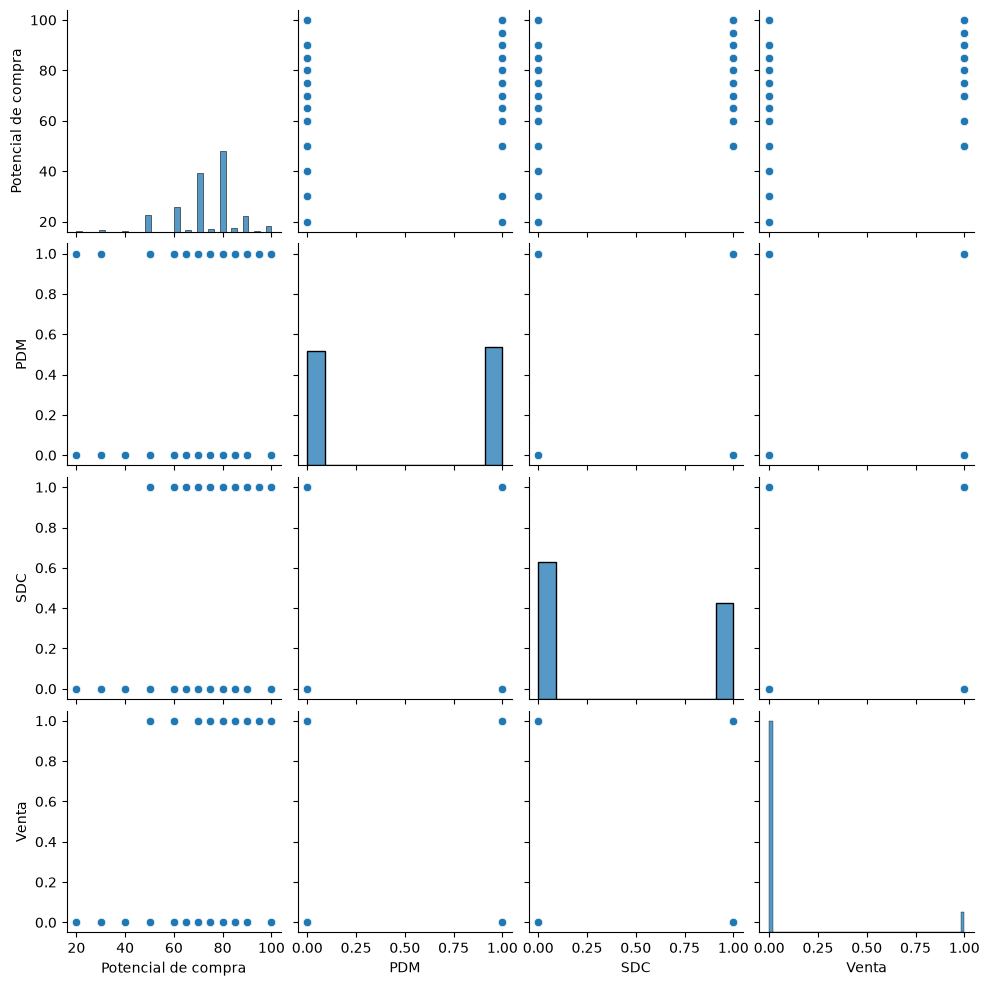

In [ ]:
sns.pairplot(df)

#PDM, SDC y Venta son variables dicotómicas (0/1), los puntos se concentran en dos niveles.

In [29]:
Corr_Factors = df_correlacion.corr()
Corr_Factors

,Potencial de compra,PDM,SDC,Venta
Potencial de compra,1.000000,0.193507,0.257919,0.263048
PDM,0.193507,1.000000,0.122142,0.166640
SDC,0.257919,0.122142,1.000000,0.238830
Venta,0.263048,0.166640,0.238830,1.000000


In [30]:
Corr_Factors1 = abs(Corr_Factors)
Corr_Factors1

,Potencial de compra,PDM,SDC,Venta
Potencial de compra,1.000000,0.193507,0.257919,0.263048
PDM,0.193507,1.000000,0.122142,0.166640
SDC,0.257919,0.122142,1.000000,0.238830
Venta,0.263048,0.166640,0.238830,1.000000


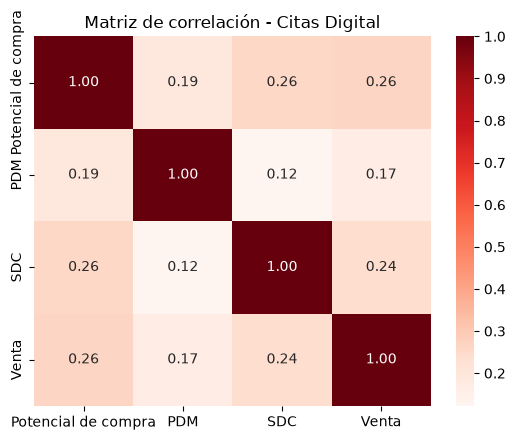

In [33]:
sns.heatmap(
    Corr_Factors1,
    cmap="Reds",
    annot=True,
    fmt=".2f"
)

plt.title("Matriz de correlación - Citas Digital")
plt.show()

El potencial de compra es la variable con mayor relación con Venta dentro de las variables analizadas (r=0.26), seguida de SDC (r=0.24) y PDM (r=0.17).